### Libraries.

In [1]:
import math
import os
import os
import sys
from typing import Literal, OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import scvi
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm

from sc_exp_design.utils import set_reproducibility

sys.path.insert(0, "../scripts")
from fetch_data import get_log_transformed_experimental_variables
from data_utils import (
    get_one_hot_encoded_protocols,
    get_one_hot_encoded_protocol_axis
)


### Constants.

In [2]:
# paths
H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# columns
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]'
]
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", "il3_[ng_ml]", "retinoic_acid_[µm]",]

# adata keys
X_CHANNEL_OBSM_KEY = "X_channel"
X_SCATTER_OSBM_KEY = "X_scatter"
X_PCA_KEY = "X_pca"
OHE_PROTOCOLS_OBS_KEY = "protocol"
OHE_PROTOCOLS_UNS_KEY = "protocol_ohe"
CONCAT_FEATS_OBSM_KEY_SUFFIX = "scatter_concat"
CONDITION_CONCAT_OBSM_KEY = "protocol_axes_concat"
STANDARDIZATION_SUFFIX = "standardized"

# reproducibility
SEED = 42
set_reproducibility(SEED)


### Reading data.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Annotating conditions.

In [4]:
# concatenated experimental variable
adata = get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL,
    CONDITION_CONCAT_OBSM_KEY
)

# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocols(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_OBS_KEY,
    OHE_PROTOCOLS_UNS_KEY
)


# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocol_axis(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_UNS_KEY
)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt3l_

### Tranforming data.

In [ ]:
# retrieving scatter features and optionally normalizing them
X_scatter = adata.obs[SCATTER_COLUMNS].values
X_scatter_mean = X_scatter.mean(0)
X_scatter_std = X_scatter.std(0)
X_scatter_standardized = (X_scatter - X_scatter_mean)/X_scatter_std
assert np.isfinite(X_scatter_std).all()
assert np.isfinite(X_scatter_standardized).all()
adata.obsm[f"{X_SCATTER_OSBM_KEY}"] = X_scatter
adata.obsm[f"{X_SCATTER_OSBM_KEY}_{STANDARDIZATION_SUFFIX}"] = X_scatter_standardized

# concatenating with channel features
X_channel = adata.X
X_channel_mean = X_channel.mean(0)
X_channel_std = X_channel.std(0)
X_channel_standardized = (X_channel - X_channel_mean)/X_channel_std
assert np.isfinite(X_channel).all()
assert np.isfinite(X_channel_standardized).all()
adata.obsm[f"{X_CHANNEL_OBSM_KEY}"] = X_channel
adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZATION_SUFFIX}"] = X_channel_standardized

# concatenating with PCs
X_pca = adata.obsm[X_PCA_KEY]
X_pca_mean = X_pca.mean(0)
X_pca_std = X_pca.std(0)
X_pca_standardized = (X_pca - X_pca_mean)/X_pca_std
assert np.isfinite(X_pca).all()
assert np.isfinite(X_pca_standardized).all()
adata.obsm[f"{X_CHANNEL_OBSM_KEY}"] = X_channel
adata.obsm[f"{X_PCA_KEY}_{STANDARDIZATION_SUFFIX}"] = X_pca_standardized
repr_keys = [k for k in adata.obsm_keys() if k.startswith("X")]
print(repr_keys)
adata

['X_pca', 'X_umap', 'X_scatter', 'X_scatter_standardized', 'X_channel', 'X_channel_standardized', 'X_pca_standardized']


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt3l_

### Function for KDE plots.

In [27]:
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

def plot_kde_channels(data_real, data_gen=None, title="", axis_ids=None):
    fig, axes = plt.subplots(1, data_real.shape[1], figsize=(45, 5))
    fig.suptitle(title)
    for idx in range(data_real.shape[1]):
        sns.kdeplot(data_real[idx], ax=axes[idx], color="blue")
        if data_gen is not None:
            sns.kdeplot(data_gen[idx], ax=axes[idx], color="red")
        axes[idx].grid(True)
        axes[idx].set_title(axis_ids[idx])
    axes[idx].legend()
    fig.show()

def get_covariance(data_real):
    mean = data_real.mean(axis=0)
    centered_data = data_real - mean
    n_samples = data_real.shape[0]
    return (centered_data.T @ centered_data) / (n_samples - 1)    

def plot_heatmap(M, xticklabels=None, yticklabels=None, annot=False, title="", xlabel="", ylabel="", figsize=(5, 5)):
    fig, axes = plt.subplots(figsize=figsize)
    fig.suptitle(title)
    sns.heatmap(
        M,
        yticklabels=yticklabels,
        xticklabels=xticklabels,
        annot=annot,
        fmt=".2f",
        annot_kws={"size": 6},
        ax=axes,
    )
    axes.set_xlabel(xlabel, fontsize=12)
    axes.set_ylabel(ylabel, fontsize=12)

    fig.tight_layout()
    fig.show()

### Visualizing each representation.

/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_52125/2856070968.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend()
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_52125/2856070968.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_52125/2856070968.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_52125/2856070968.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend()
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_52125/2856070968.py:16: UserWarning: FigureCanvasAgg 

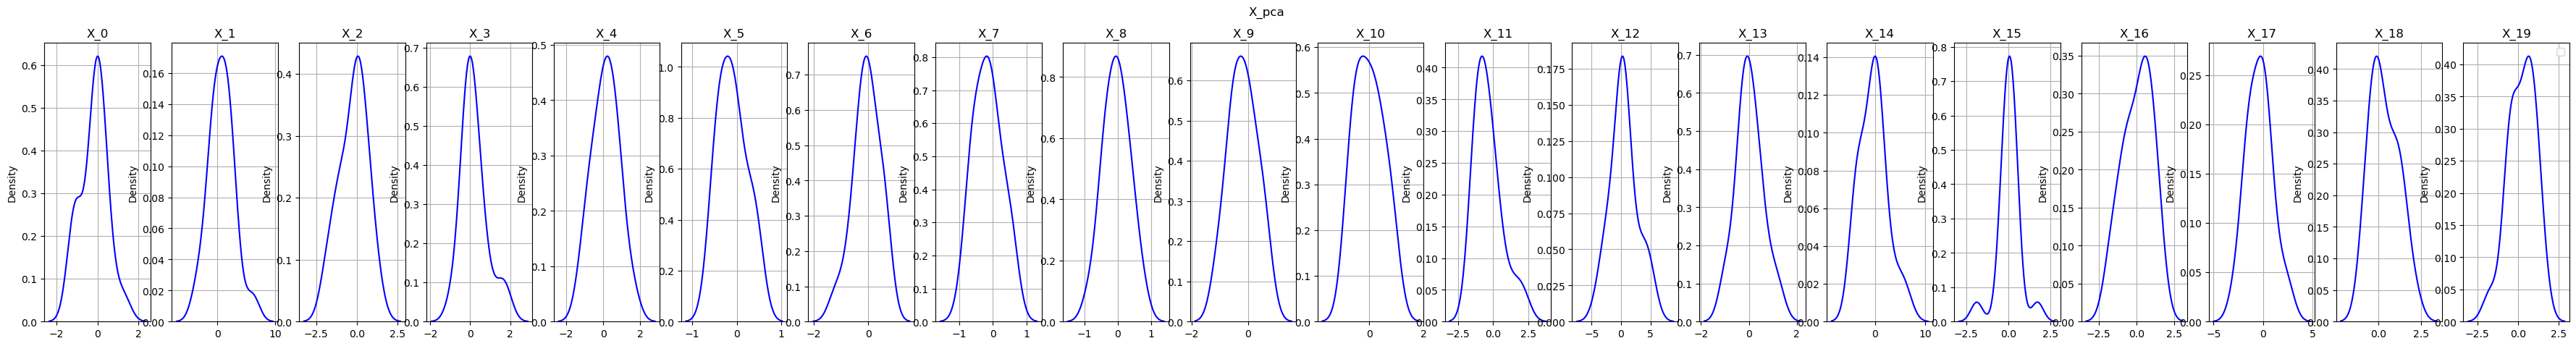

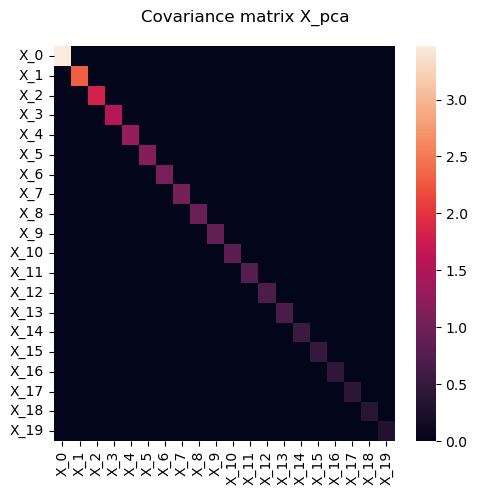

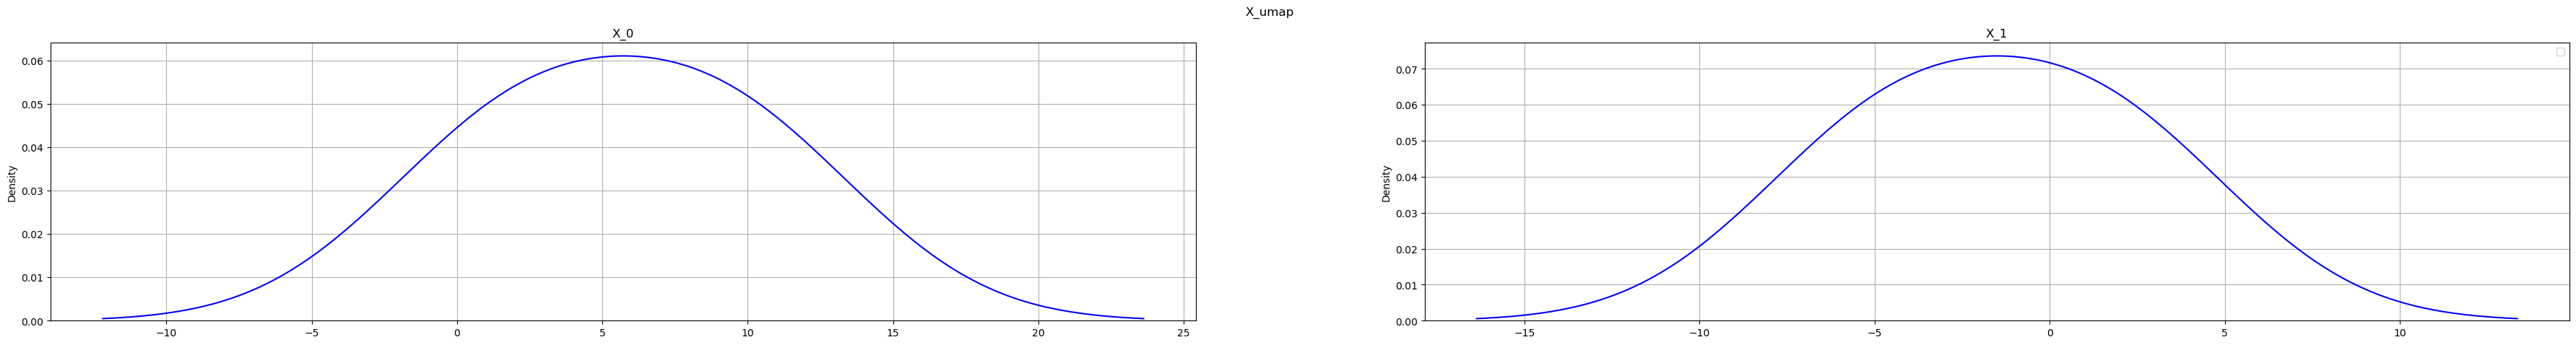

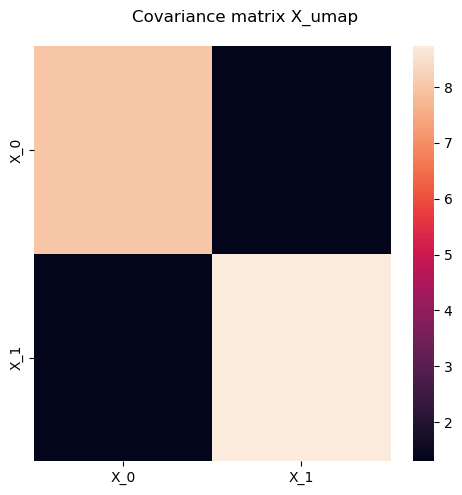

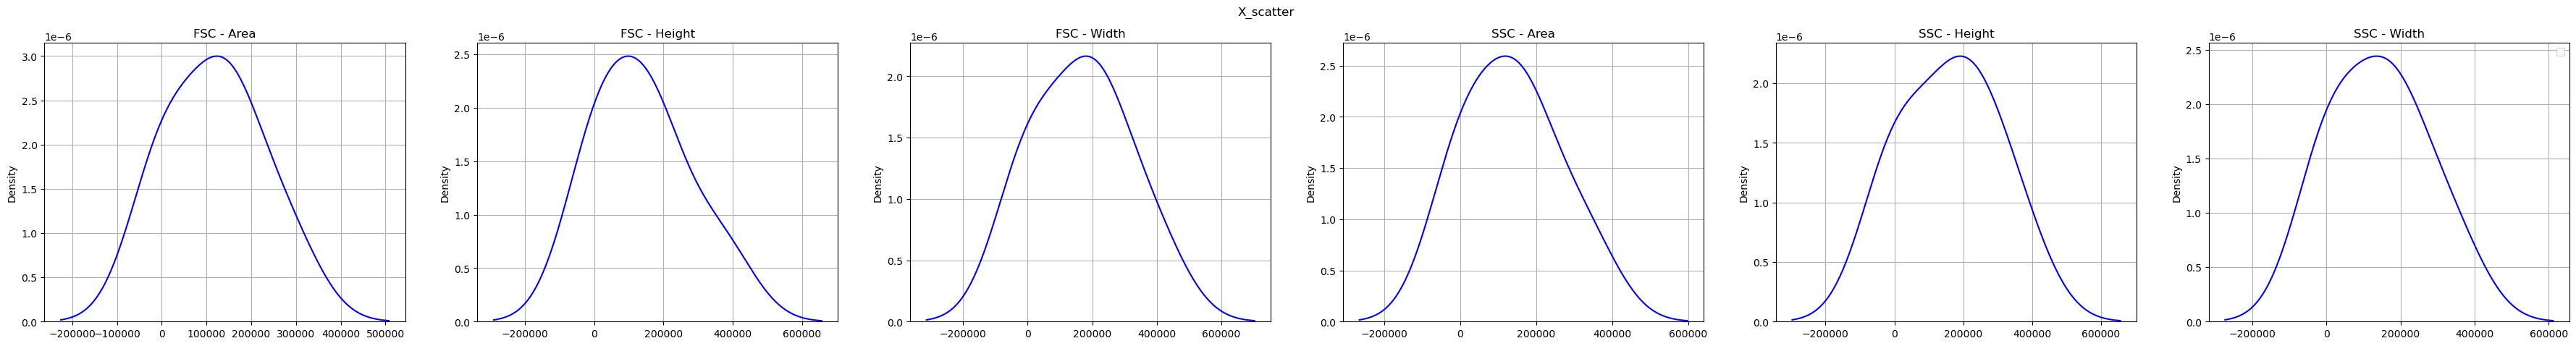

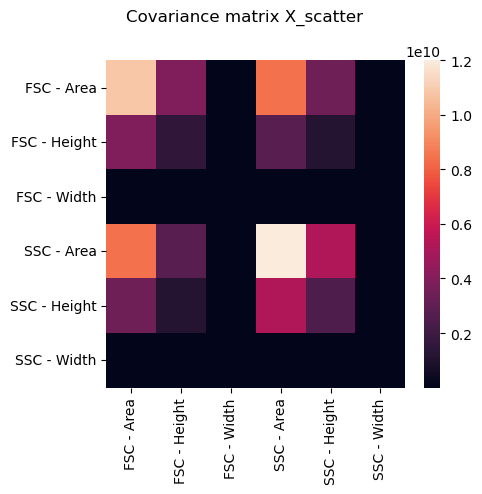

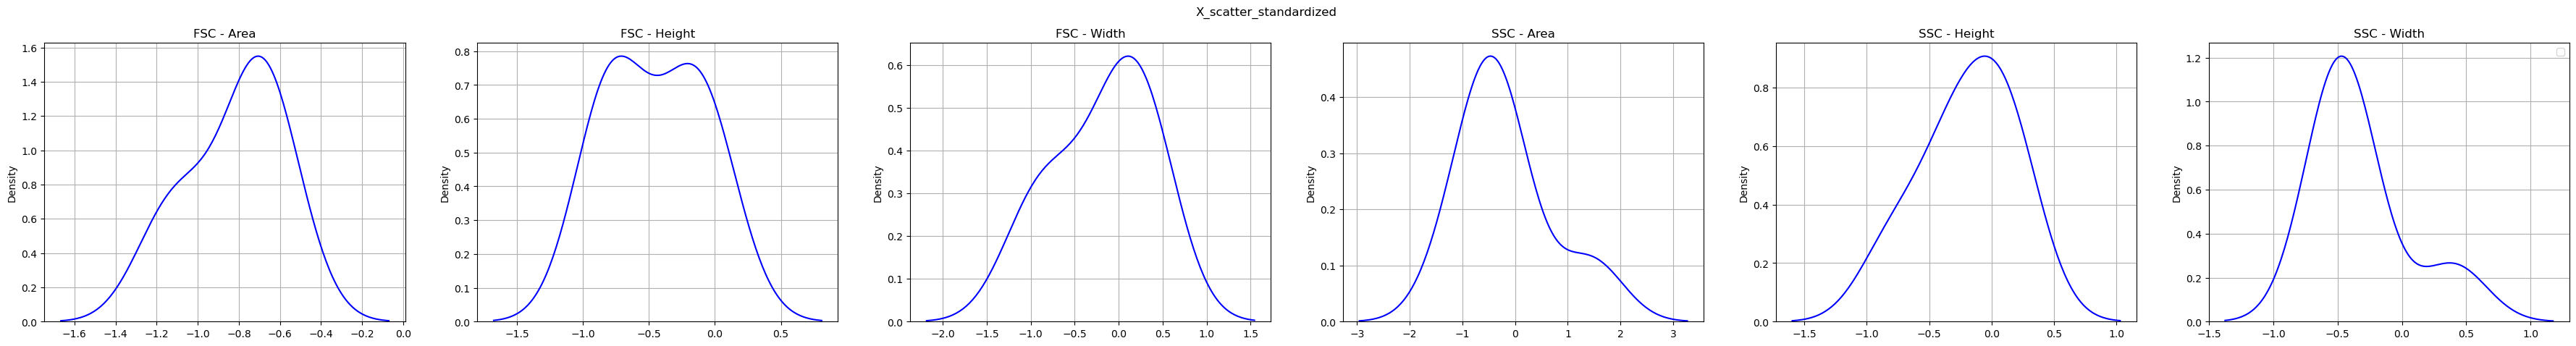

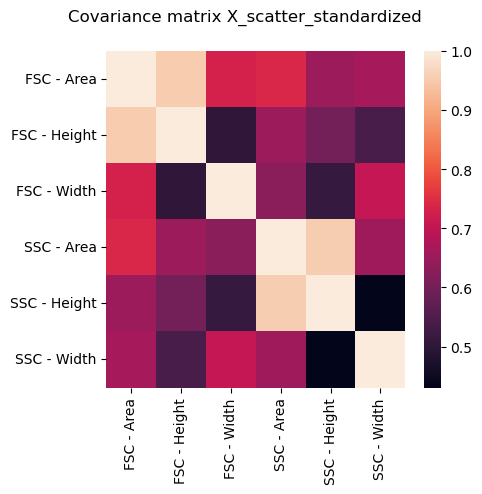

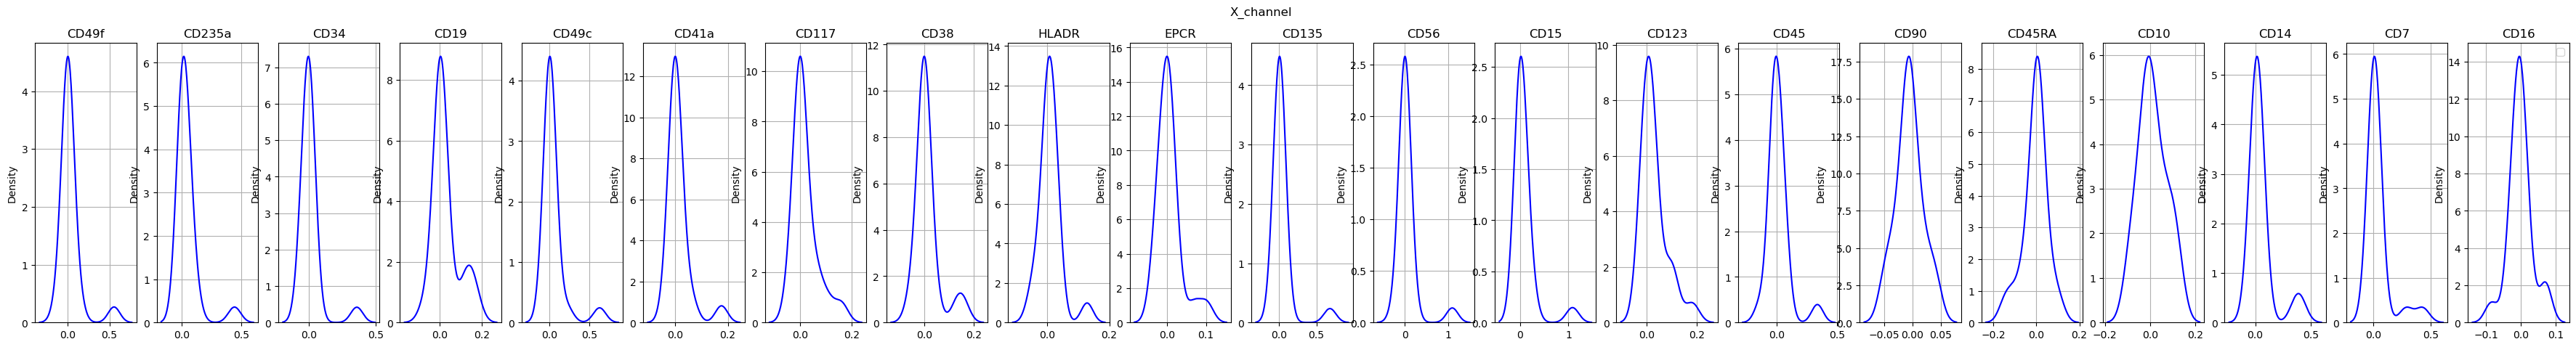

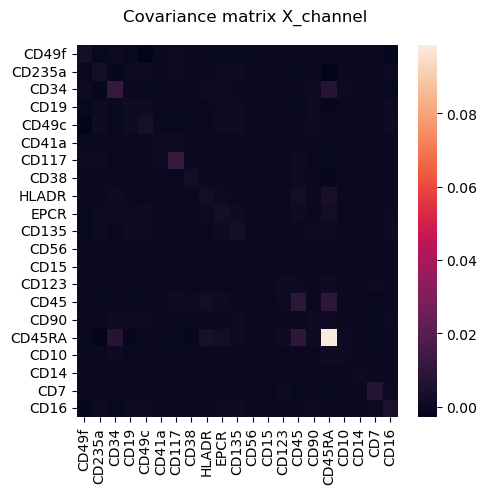

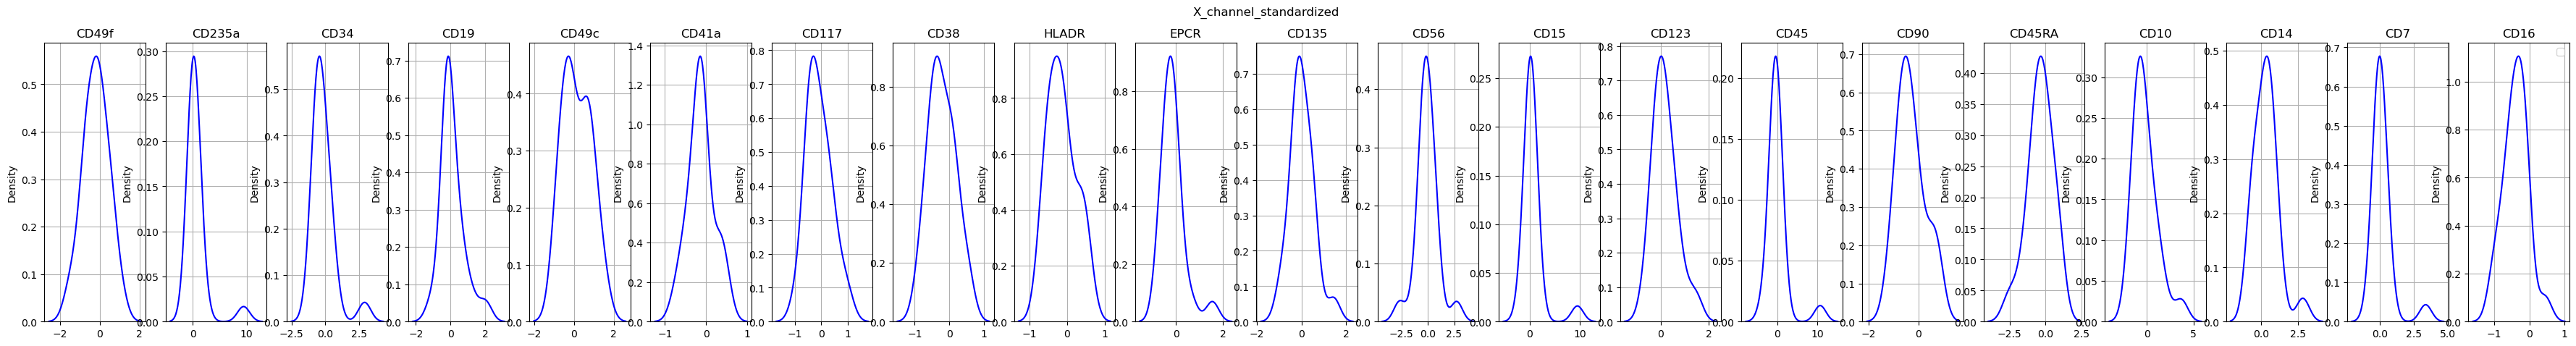

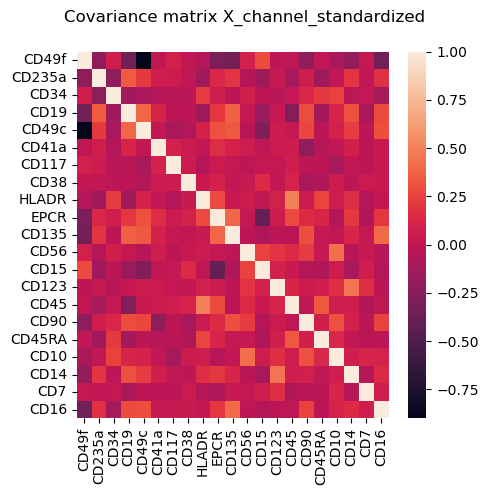

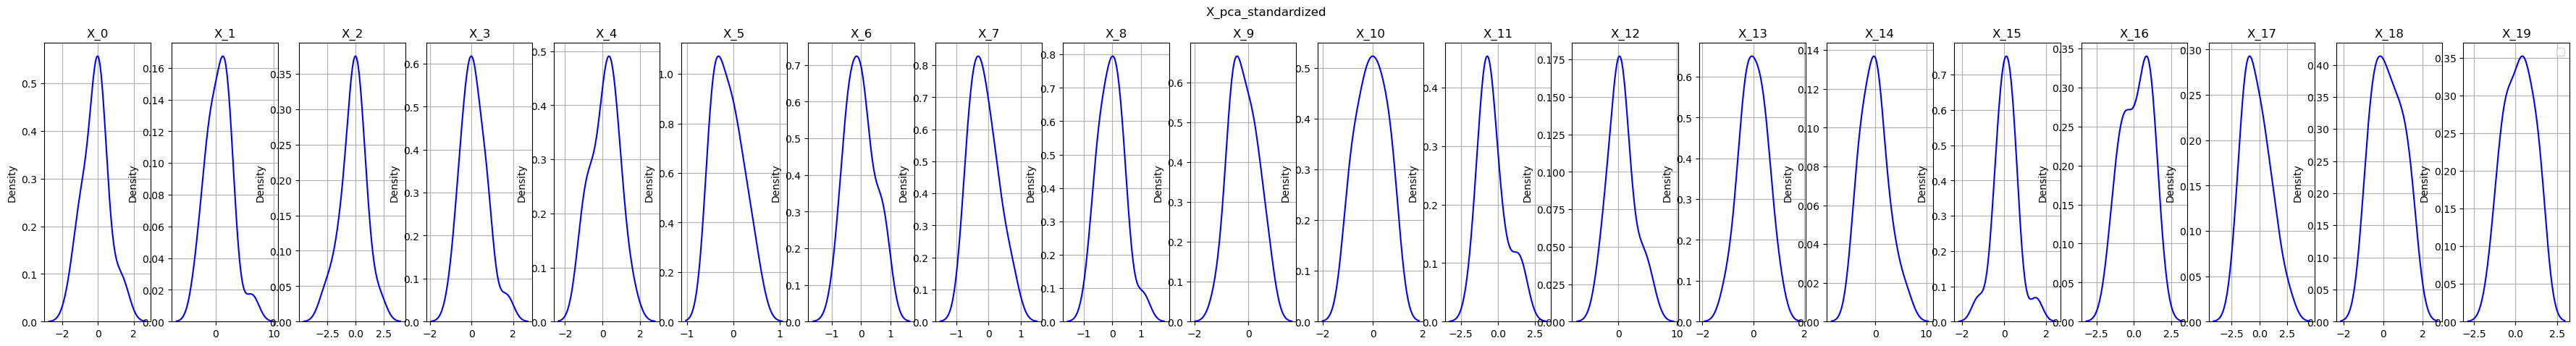

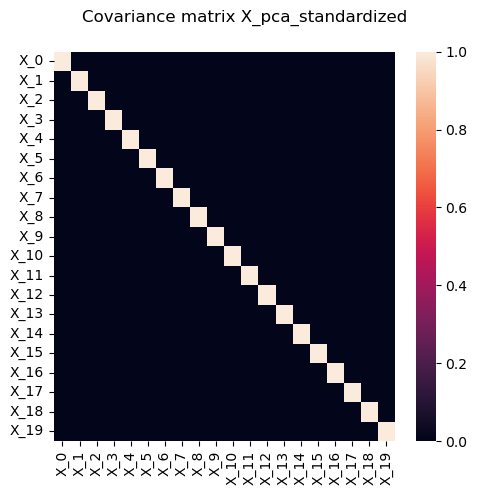

In [28]:
for repr in repr_keys:

    X_repr = adata.obsm[repr]


    if "X_scatter" in repr:
        axis_ids = SCATTER_COLUMNS
    elif "X_channel" in repr:
        axis_ids = adata.var_names
    else:
        axis_ids = [f"X_{idx}" for idx in range(X_repr.shape[-1])]
    plot_kde_channels(
        X_repr, data_gen=None, title=repr, axis_ids=axis_ids
    )

    cov = get_covariance(X_repr)
    plot_heatmap(
        cov,
        xticklabels=axis_ids,
        yticklabels=axis_ids,
        title=f"Covariance matrix {repr}",
    )